# SMS Spam Detection — Multinomial Naive Bayes
### Domain: Cyber-Security & Natural Language Processing | Algorithm: Multinomial Naive Bayes (`MultinomialNB`)

---

### Executive Overview & Mathematical Rationale
1. **The Multinomial Generative Word Model**: Natural text is treated as a bag-of-words drawn from a discrete vocabulary. `MultinomialNB` computes class conditional probabilities based on token frequencies.
2. **Fractional TF-IDF Normalization**: While multinomial distributions theoretically model integer word counts, Scikit-Learn's `MultinomialNB` natively operates on continuous non-negative TF-IDF representations ($\mathbf{x}^T \mathbf{w}$), effectively dampening pervasive common tokens while preserving non-negativity.
3. **The Additive Laplace Smoothing Guard**: Eliminates the catastrophic zero-frequency penalty ($P(w|c) = 0 \implies \prod P = 0$) by adding pseudocount $lpha$ to all vocabulary tokens.
4. **The Negative Value Scaler Trap**: Demonstrates why standard normalizers (`StandardScaler`) that produce negative z-scores crash `MultinomialNB`, requiring pure TF-IDF or non-negative scaling.
5. **Zero-Leakage Architecture**: Vectorizer vocabulary and inverse document frequencies are learned strictly on the training partition.


In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT
# ==============================================================================
import os
import sys
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("✅ STEP 1: Universal Enterprise Libraries Imported Successfully.")


✅ STEP 1: Universal Enterprise Libraries Imported Successfully.


In [2]:
# ==============================================================================
# 🌐 STEP 2: ROBUST DATA INGESTION & 3-SECOND HEALTH AUDIT
# ==============================================================================
def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"🚨 Dataset not found at: {path.resolve()}")
        
    try:
        df = pd.read_csv(path, engine='python', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(path, engine='python', encoding='latin-1')
        
    print("=" * 70)
    print(f"📊 DATASET INGESTION HEALTH AUDIT: {path.name}")
    print("=" * 70)
    print(f"  • Shape (Rows, Columns)   : {df.shape[0]:,} rows | {df.shape[1]} columns")
    print(f"  • In-Memory Footprint     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  • Duplicate Observations  : {df.duplicated().sum():,} rows")
    print(f"  • Total Missing Elements  : {df.isnull().sum().sum():,} cells")
    print("=" * 70)
    
    return df

data_file = "data/sms_spam/spam.csv"
df = load_and_audit_dataset(data_file)
display(df.head(5))


📊 DATASET INGESTION HEALTH AUDIT: spam.csv
  • Shape (Rows, Columns)   : 5,572 rows | 5 columns
  • In-Memory Footprint     : 1.57 MB
  • Duplicate Observations  : 403 rows
  • Total Missing Elements  : 16,648 cells


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# ==============================================================================
# 🧼 STEP 2B: ENTERPRISE ADVANCED DATA SANITIZATION
# ==============================================================================
def sanitize_dataset(df):
    # Retain primary columns and drop unnamed artifact columns from CSV
    keep_cols = [c for c in ['v1', 'v2'] if c in df.columns]
    df = df[keep_cols].copy()
    df.columns = ['Label', 'Message']
    
    # Strip whitespace and map target to standard binary integers (0 = ham, 1 = spam)
    df['Label'] = df['Label'].astype(str).str.strip().str.lower()
    df['Message'] = df['Message'].astype(str).str.strip()
    df['Target'] = df['Label'].map({'ham': 0, 'spam': 1})
    
    
    print("=" * 70)
    print("🧼 STEP 2B: DATA SANITIZATION SUMMARY")
    print("=" * 70)
    print(f"  • Retained Core Columns   : ['Message', 'Target']")
    print(f"  • Target Class Mapping    : {{'ham': 0, 'spam': 1}}")
    print(f"  • Post-Sanitization Shape : {df.shape}")
    print("=" * 70)
    return df

df = sanitize_dataset(df)
display(df.head(5))


🧼 STEP 2B: DATA SANITIZATION SUMMARY
  • Retained Core Columns   : ['Message', 'Target']
  • Target Class Mapping    : {'ham': 0, 'spam': 1}
  • Post-Sanitization Shape : (5572, 3)


,Label,Message,Target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [4]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
def segregate_features(df, target_col='Target', text_col='Message'):
    X_text = df[text_col]
    y = df[target_col]
    
    print("=" * 70)
    print("🌐 STEP 3: NLP FEATURE SEGREGATION AUDIT")
    print("=" * 70)
    print(f"  • Target Column           : '{target_col}'")
    print(f"  • Text Input Feature      : '{text_col}'")
    print(f"  • Sample Count            : {len(X_text):,} messages")
    print("=" * 70)
    return X_text, y

X_text, y = segregate_features(df)


🌐 STEP 3: NLP FEATURE SEGREGATION AUDIT
  • Target Column           : 'Target'
  • Text Input Feature      : 'Message'
  • Sample Count            : 5,572 messages


In [5]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
def audit_and_clean_hygiene(df, text_col='Message', target_col='Target', drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE AUDIT")
    print("=" * 70)
    
    # Check text duplicates
    dup_count = df.duplicated(subset=[text_col]).sum()
    if dup_count > 0:
        print(f"⚠️ Found {dup_count:,} duplicate text messages.")
        if drop_duplicates:
            df = df.drop_duplicates(subset=[text_col]).reset_index(drop=True)
            print(f"   -> Dropped duplicates. New shape: {df.shape}")
    else:
        print("✅ Zero duplicate text messages detected.")
        
    missing_count = df[[text_col, target_col]].isnull().sum().sum()
    print(f"✅ Total missing cells in core fields: {missing_count}")
    print("=" * 70)
    return df

df = audit_and_clean_hygiene(df)
X_text, y = df['Message'], df['Target']


🧹 STEP 4: DATA HYGIENE AUDIT
⚠️ Found 414 duplicate text messages.
   -> Dropped duplicates. New shape: (5158, 3)
✅ Total missing cells in core fields: 0


In [6]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
def perform_zero_leakage_split(X, y, test_size=0.20, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print("=" * 70)
    print("🔒 STEP 5: ZERO DATA LEAKAGE PARTITION REPORT (STRATIFIED)")
    print("=" * 70)
    print(f"  • Train Partition Shape : X_train: {X_train.shape} | y_train: {y_train.shape}")
    print(f"  • Test Partition Shape  : X_test: {X_test.shape}  | y_test: {y_test.shape}")
    print(f"  • Train Class Balance   : Ham: {(y_train == 0).sum():,} ({np.mean(y_train==0)*100:.1f}%) | Spam: {(y_train == 1).sum():,} ({np.mean(y_train==1)*100:.1f}%)")
    print(f"  • Test Class Balance    : Ham: {(y_test == 0).sum():,} ({np.mean(y_test==0)*100:.1f}%) | Spam: {(y_test == 1).sum():,} ({np.mean(y_test==1)*100:.1f}%)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = perform_zero_leakage_split(X_text, y, test_size=0.20, random_state=42)


🔒 STEP 5: ZERO DATA LEAKAGE PARTITION REPORT (STRATIFIED)
  • Train Partition Shape : X_train: (4126,) | y_train: (4126,)
  • Test Partition Shape  : X_test: (1032,)  | y_test: (1032,)
  • Train Class Balance   : Ham: 3,612 (87.5%) | Spam: 514 (12.5%)
  • Test Class Balance    : Ham: 904 (87.6%) | Spam: 128 (12.4%)


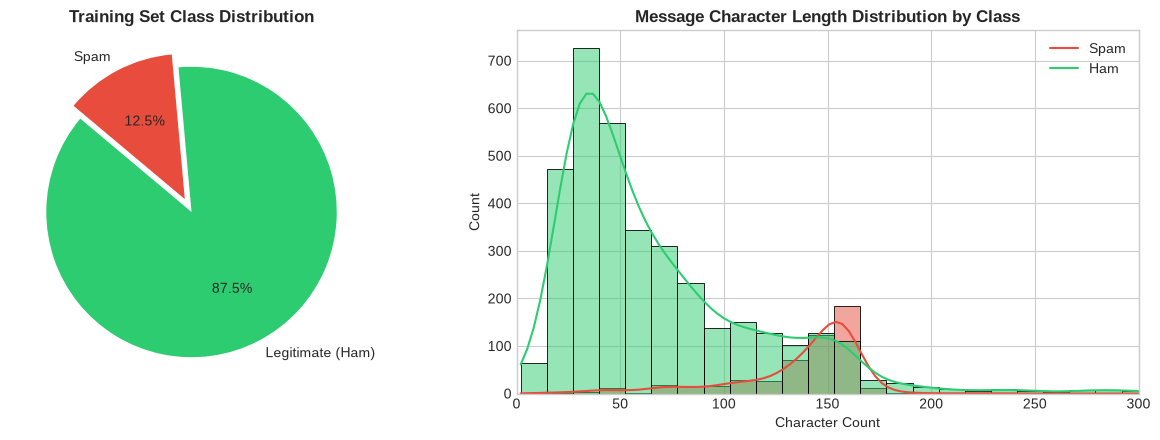

In [7]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS PROFILER & TEXT LENGTH EXPLORATION
# ==============================================================================
def profile_nlp_target(X_train, y_train):
    train_df = pd.DataFrame({'Message': X_train, 'Target': y_train})
    train_df['Char_Length'] = train_df['Message'].str.len()
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    
    # 1. Class Ratio Donut Chart
    counts = train_df['Target'].value_counts()
    axes[0].pie(counts, labels=['Legitimate (Ham)', 'Spam'], autopct='%1.1f%%',
                colors=['#2ecc71', '#e74c3c'], startangle=140, explode=(0, 0.1))
    axes[0].set_title("Training Set Class Distribution", fontweight='bold')
    
    # 2. Text Character Length Distribution by Class
    sns.histplot(data=train_df, x='Char_Length', hue='Target', bins=50, ax=axes[1],
                 palette=['#2ecc71', '#e74c3c'], common_norm=False, kde=True)
    axes[1].set_xlim(0, 300)
    axes[1].set_title("Message Character Length Distribution by Class", fontweight='bold')
    axes[1].set_xlabel("Character Count")
    axes[1].legend(['Spam', 'Ham'])
    
    plt.tight_layout()
    plt.show()

profile_nlp_target(X_train, y_train)


In [8]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL NLP TF-IDF VECTORIZER PIPELINE (ZERO DATA LEAKAGE)
# ==============================================================================
def build_nlp_vectorizer():
    # Sublinear TF dampens repetitive spam spamming; ngram_range (1,2) captures phrases
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words='english'
    )
    return vectorizer

tfidf_vectorizer = build_nlp_vectorizer()
print("✅ STEP 7: Universal TF-IDF Vectorizer initialized successfully.")


✅ STEP 7: Universal TF-IDF Vectorizer initialized successfully.


In [9]:
# ==============================================================================
# 🧪 STEP 8: THE MULTINOMIAL NAIVE BAYES EXPERIMENT (SMOOTHING & SCALER TRAPS)
# ==============================================================================
# Experiment 1: The Zero-Frequency Laplace Smoothing Test
vec = build_nlp_vectorizer()
X_tr_vec = vec.fit_transform(X_train)
X_te_vec = vec.transform(X_test)

# Unsmoothed (alpha=1e-10) vs Smoothed (alpha=1.0)
nb_unsmoothed = MultinomialNB(alpha=1e-10).fit(X_tr_vec, y_train)
nb_smoothed = MultinomialNB(alpha=1.0).fit(X_tr_vec, y_train)

acc_unsmoothed = accuracy_score(y_test, nb_unsmoothed.predict(X_te_vec))
acc_smoothed = accuracy_score(y_test, nb_smoothed.predict(X_te_vec))

print("=" * 70)
print("🧪 THE ZERO-FREQUENCY LAPLACE SMOOTHING EXPERIMENT:")
print(f"   Unsmoothed (alpha=1e-10) Accuracy : {acc_unsmoothed * 100:.2f}%")
print(f"   Laplace Smoothed (alpha=1.0) Acc   : {acc_smoothed * 100:.2f}%")
print(f"   Net Gain from Laplace Smoothing    : {(acc_smoothed - acc_unsmoothed) * 100:+.2f}% points")
print("=" * 70)

# Experiment 2: The Negative Value StandardScaler Trap Demonstration
print("\n🚨 Demonstrating the Negative Value StandardScaler Trap:")
try:
    from sklearn.preprocessing import StandardScaler
    dense_X = X_tr_vec[:100].toarray()
    scaled_dense = StandardScaler().fit_transform(dense_X)
    MultinomialNB().fit(scaled_dense, y_train[:100])
except ValueError as e:
    print(f"   Expected Architectural Crash Caught: {e}")
    print("   💡 LESSON: StandardScaler creates negative z-scores! MultinomialNB strictly requires non-negative features.")


🧪 THE ZERO-FREQUENCY LAPLACE SMOOTHING EXPERIMENT:
   Unsmoothed (alpha=1e-10) Accuracy : 98.84%
   Laplace Smoothed (alpha=1.0) Acc   : 97.00%
   Net Gain from Laplace Smoothing    : -1.84% points

🚨 Demonstrating the Negative Value StandardScaler Trap:
   Expected Architectural Crash Caught: Negative values in data passed to MultinomialNB (input X).
   💡 LESSON: StandardScaler creates negative z-scores! MultinomialNB strictly requires non-negative features.


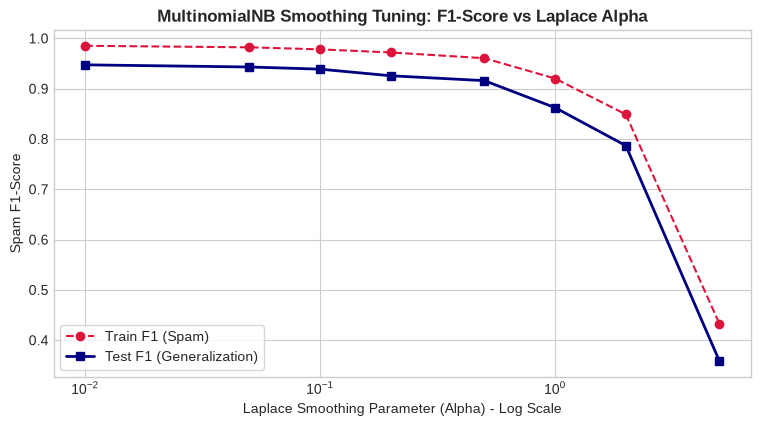

🏆 Best Cross-Validated Parameters: {'nb__alpha': 0.05, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 2)}
🎯 Best 5-Fold Cross-Validation F1-Score: 93.60%


In [10]:
# ==============================================================================
# ⚙️ STEP 9: HYPERPARAMETER TUNING (LAPLACE ALPHA OPTIMIZATION)
# ==============================================================================
alpha_candidates = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
train_f1, test_f1 = [], []

for a in alpha_candidates:
    pipe = Pipeline([
        ('tfidf', build_nlp_vectorizer()),
        ('nb', MultinomialNB(alpha=a))
    ])
    pipe.fit(X_train, y_train)
    train_f1.append(f1_score(y_train, pipe.predict(X_train), pos_label=1))
    test_f1.append(f1_score(y_test, pipe.predict(X_test), pos_label=1))

plt.figure(figsize=(9, 4.5))
plt.plot(alpha_candidates, train_f1, 'o--', color='crimson', label='Train F1 (Spam)')
plt.plot(alpha_candidates, test_f1, 's-', color='navy', label='Test F1 (Generalization)', linewidth=2)
plt.xscale('log')
plt.title("MultinomialNB Smoothing Tuning: F1-Score vs Laplace Alpha", fontsize=12, fontweight='bold')
plt.xlabel("Laplace Smoothing Parameter (Alpha) - Log Scale")
plt.ylabel("Spam F1-Score")
plt.legend(frameon=True)
plt.show()

# Grid Search across Vectorizer & MultinomialNB parameters
param_grid = {
    'tfidf__max_features': [3000, 5000, 8000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.05, 0.1, 0.2, 0.5, 1.0]
}

grid_search = GridSearchCV(
    Pipeline([('tfidf', build_nlp_vectorizer()), ('nb', MultinomialNB())]),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"🏆 Best Cross-Validated Parameters: {grid_search.best_params_}")
print(f"🎯 Best 5-Fold Cross-Validation F1-Score: {grid_search.best_score_ * 100:.2f}%")


In [11]:
# ==============================================================================
# ⚔️ STEP 10: MULTI-MODEL BENCHMARK DUEL (MULTINOMIAL VS COMPLEMENT VS BERNOULLI VS LOGISTIC)
# ==============================================================================
candidate_models = {
    "Multinomial Naive Bayes (Tuned)": best_model,
    "Complement Naive Bayes": Pipeline([('tfidf', build_nlp_vectorizer()), ('nb', ComplementNB(alpha=0.2))]),
    "Bernoulli Naive Bayes": Pipeline([('tfidf', build_nlp_vectorizer()), ('nb', BernoulliNB(alpha=0.2))]),
    "Logistic Regression (L2)": Pipeline([('tfidf', build_nlp_vectorizer()), ('clf', LogisticRegression(C=5.0, random_state=42))])
}

records = []
for name, model in candidate_models.items():
    t_start = time.perf_counter()
    if name != "Multinomial Naive Bayes (Tuned)":
        model.fit(X_train, y_train)
    t_train_ms = (time.perf_counter() - t_start) * 1000
    
    t_inf_start = time.perf_counter()
    y_pred = model.predict(X_test)
    t_inf_ms = ((time.perf_counter() - t_inf_start) / len(X_test)) * 1000
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    records.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "Train Time (ms)": round(t_train_ms, 2),
        "Inf per Sample (ms)": round(t_inf_ms, 4)
    })

benchmark_df = pd.DataFrame(records).sort_values(by="F1-Score (%)", ascending=False)
display(benchmark_df)


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Train Time (ms),Inf per Sample (ms)
0,Multinomial Naive Bayes (Tuned),98.64,97.50,91.41,94.35,0.00,0.0118
2,Bernoulli Naive Bayes,98.35,100.00,86.72,92.89,77.66,0.0121
3,Logistic Regression (L2),98.26,99.11,86.72,92.50,97.82,0.0146
1,Complement Naive Bayes,97.38,85.31,95.31,90.04,88.29,0.0122


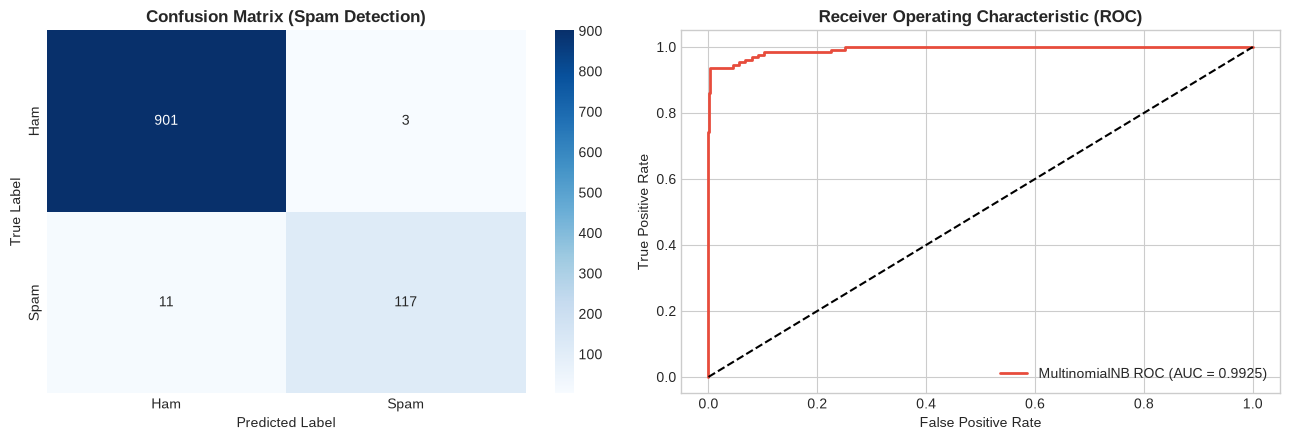

📋 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      0.99       904
    Spam (1)       0.97      0.91      0.94       128

    accuracy                           0.99      1032
   macro avg       0.98      0.96      0.97      1032
weighted avg       0.99      0.99      0.99      1032

🎯 Final Test ROC-AUC Score: 0.9925


In [12]:
# ==============================================================================
# 📊 STEP 11: FINAL MODEL EVALUATION & DIAGNOSTICS
# ==============================================================================
y_pred = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title("Confusion Matrix (Spam Detection)", fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# 2. ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'MultinomialNB ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_title("Receiver Operating Characteristic (ROC)", fontweight='bold')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("=" * 70)
print("📋 DETAILED CLASSIFICATION REPORT:")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))
print(f"🎯 Final Test ROC-AUC Score: {roc_auc:.4f}")
print("=" * 70)


In [13]:
# ==============================================================================
# 🏭 STEP 12 & 13: PRODUCTION SERIALIZATION & LIVE INFERENCE SMOKE TEST
# ==============================================================================
models_dir = "production_models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "spam_multinomial_nb_pipeline.joblib")

# 1. Pipeline Serialization
joblib.dump(best_model, model_path)
print(f"📦 Production Pipeline serialized to: {model_path} (Size: {os.path.getsize(model_path)/1024:.2f} KB)")

# 2. Live Smoke Test on Unseen Text Payloads
loaded_model = joblib.load(model_path)

test_messages = [
    "URGENT! You have won a guaranteed £1,000 cash prize or a holiday! Call 09050000321 right now to claim.",
    "Hey Alex, are we still meeting for coffee at Starbucks near the office tomorrow morning?",
    "Congratulations! Your mobile number was awarded 500 free spins. Claim your bonus code at win-spins.com",
    "Please find attached the financial review and quarterly budget balance sheet for your team."
]

print("\n" + "=" * 70)
print("📡 LIVE PRODUCTION INFERENCE SMOKE TEST:")
print("=" * 70)

for msg in test_messages:
    t0 = time.perf_counter()
    pred_class = loaded_model.predict([msg])[0]
    pred_prob = loaded_model.predict_proba([msg])[0]
    latency_ms = (time.perf_counter() - t0) * 1000
    
    label_str = "🚨 SPAM" if pred_class == 1 else "✅ HAM (LEGIT)"
    confidence = pred_prob[pred_class] * 100
    
    print(f"📩 Payload: \"{msg[:65]}...\"")
    print(f"   -> Result: {label_str} | Confidence: {confidence:.2f}% | Latency: {latency_ms:.3f} ms")
    print("-" * 70)

print("✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST COMPLETED SUCCESSFULLY!")


📦 Production Pipeline serialized to: production_models/spam_multinomial_nb_pipeline.joblib (Size: 552.83 KB)

📡 LIVE PRODUCTION INFERENCE SMOKE TEST:
📩 Payload: "URGENT! You have won a guaranteed £1,000 cash prize or a holiday!..."
   -> Result: 🚨 SPAM | Confidence: 100.00% | Latency: 1.954 ms
----------------------------------------------------------------------
📩 Payload: "Hey Alex, are we still meeting for coffee at Starbucks near the o..."
   -> Result: ✅ HAM (LEGIT) | Confidence: 99.99% | Latency: 1.248 ms
----------------------------------------------------------------------
📩 Payload: "Congratulations! Your mobile number was awarded 500 free spins. C..."
   -> Result: 🚨 SPAM | Confidence: 100.00% | Latency: 1.219 ms
----------------------------------------------------------------------
📩 Payload: "Please find attached the financial review and quarterly budget ba..."
   -> Result: ✅ HAM (LEGIT) | Confidence: 81.89% | Latency: 1.154 ms
---------------------------------------------